In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('drom_archive_cleaned_2018-2025.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 16 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Название машины             1000000 non-null  str    
 1   Год                         1000000 non-null  float64
 2   Дата размещения объявления  1000000 non-null  str    
 3   Цена                        1000000 non-null  float64
 4   Объем двигателя             1000000 non-null  float64
 5   Тип двигателя               1000000 non-null  str    
 6   Мощность                    1000000 non-null  float64
 7   Коробка передач             1000000 non-null  str    
 8   Привод                      1000000 non-null  str    
 9   Пробег                      1000000 non-null  float64
 10  Руль                        1000000 non-null  str    
 11  Поколение                   1000000 non-null  float64
 12  Рестайлинг                  1000000 non-null  float64
 13  Тип кузов

In [4]:
df.shape

(1000000, 16)

In [5]:
df.head()

,Название машины,Год,Дата размещения объявления,Цена,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,Рестайлинг,Тип кузова,Метка,Город
0,Toyota WiLL VS,2001.0,2018-01-12,255000.0,1.8,бензин,190.0,АКПП,передний,200000.0,правый,1.0,0.0,хэтчбек 5 дв.,toyota,Екатеринбург
1,Honda CR-V,2002.0,2023-09-07,795000.0,2.4,бензин,160.0,АКПП,4WD,215000.0,левый,2.0,0.0,джип/suv 5 дв.,honda,Иркутск
2,Mercedes-Benz S-Class,2002.0,2024-07-05,500000.0,5.0,бензин,306.0,АКПП,задний,350000.0,левый,4.0,0.0,седан,mercedes-benz,Оренбург
3,Лада 4x4 2121 Нива,2015.0,2018-05-26,370000.0,1.7,бензин,83.0,МКПП,4WD,60000.0,левый,1.0,0.0,джип/suv 3 дв.,lada,Краснодар
4,Mazda Mazda3,2008.0,2022-12-28,589000.0,2.0,бензин,150.0,АКПП,передний,273000.0,левый,1.0,1.0,хэтчбек 5 дв.,mazda,Кемерово


In [6]:
# сокращенный датасет для визуализации
df_eda = df.sample(n=100_000, random_state=42)

In [7]:
from sklearn.preprocessing import LabelEncoder

categories = ['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Тип кузова', 'Метка', 'Город', 'Дата размещения объявления', 'Руль', 'Дата размещения объявления']
label_encoder = LabelEncoder()
df_eda_encode = df_eda.copy()

for col in categories:
    df_eda_encode[col] = label_encoder.fit_transform(df_eda_encode[col])

'''
label_encoder = LabelEncoder()
df['Метка'] = label_encoder.fit_transform(df['Метка'])
df['Название машины'] = label_encoder.fit_transform(df['Название машины'])
df.info()
'''

"\nlabel_encoder = LabelEncoder()\ndf['Метка'] = label_encoder.fit_transform(df['Метка'])\ndf['Название машины'] = label_encoder.fit_transform(df['Название машины'])\ndf.info()\n"

<Axes: >

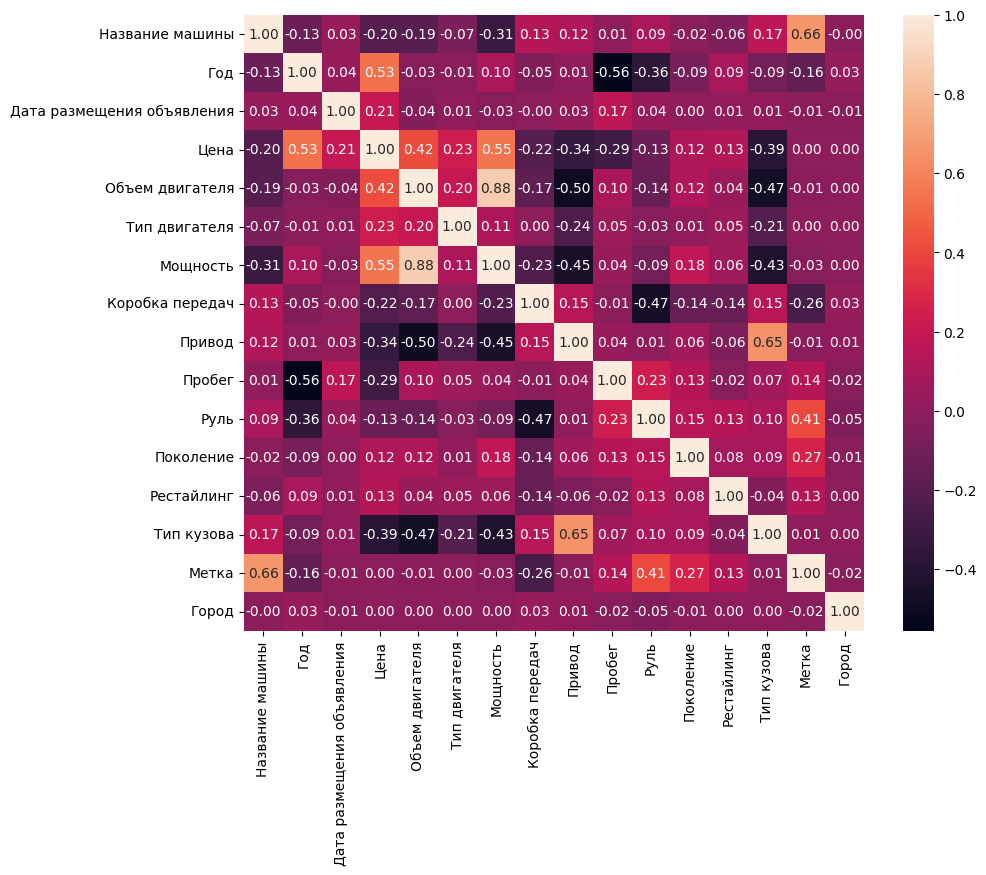

In [9]:
corr_matrix = df_eda_encode.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')

Text(0, 0.5, 'Количество автомобилей')

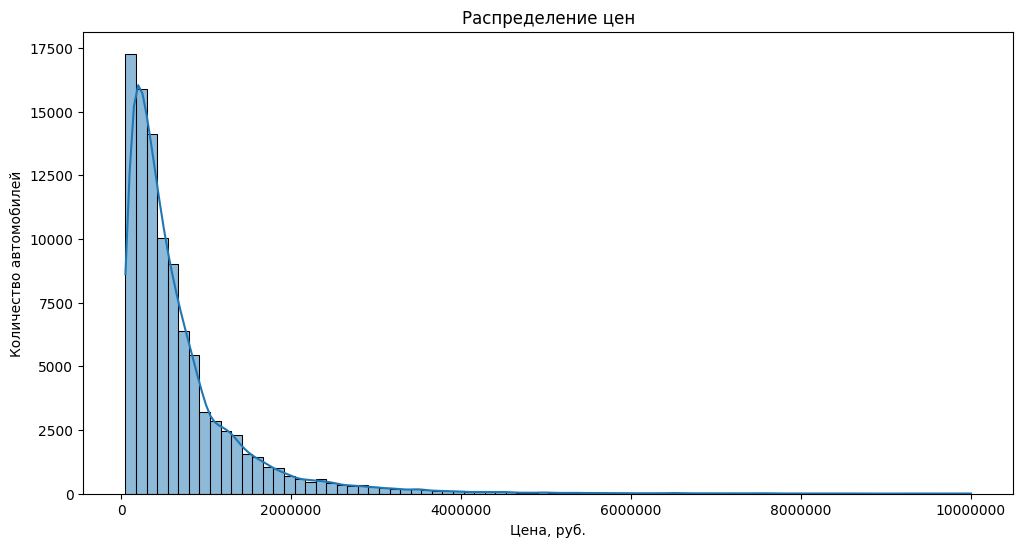

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(df_eda["Цена"], bins=80, kde=True)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Распределение цен')
plt.xlabel("Цена, руб.")
plt.ylabel("Количество автомобилей")

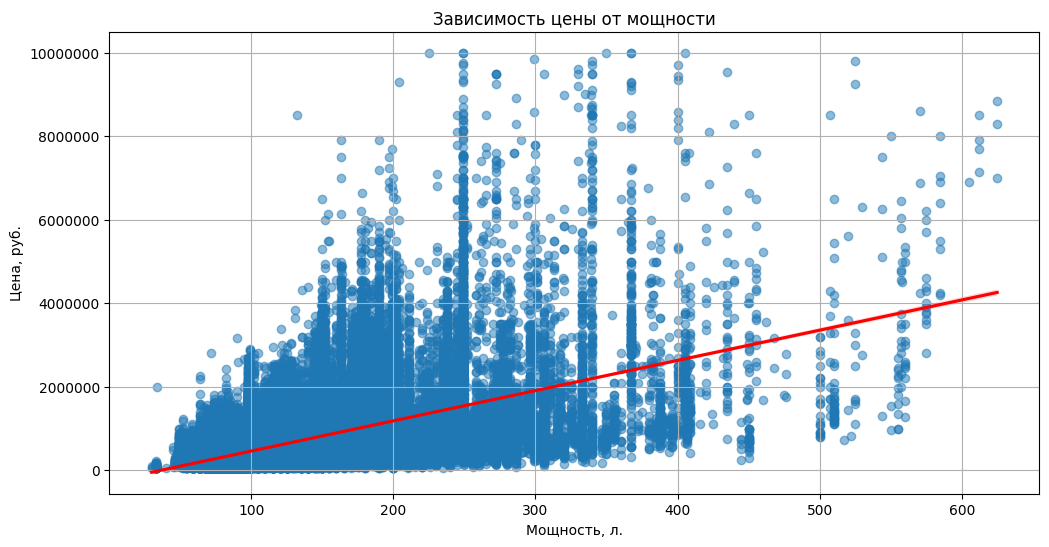

In [11]:
plt.figure(figsize=(12,6))
sns.regplot(x='Мощность', y='Цена', data=df_eda, scatter_kws={'alpha': 0.5}, line_kws={"color":"red"})
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Зависимость цены от мощности')
plt.xlabel("Мощность, л.")
plt.ylabel("Цена, руб.")
plt.grid(True)

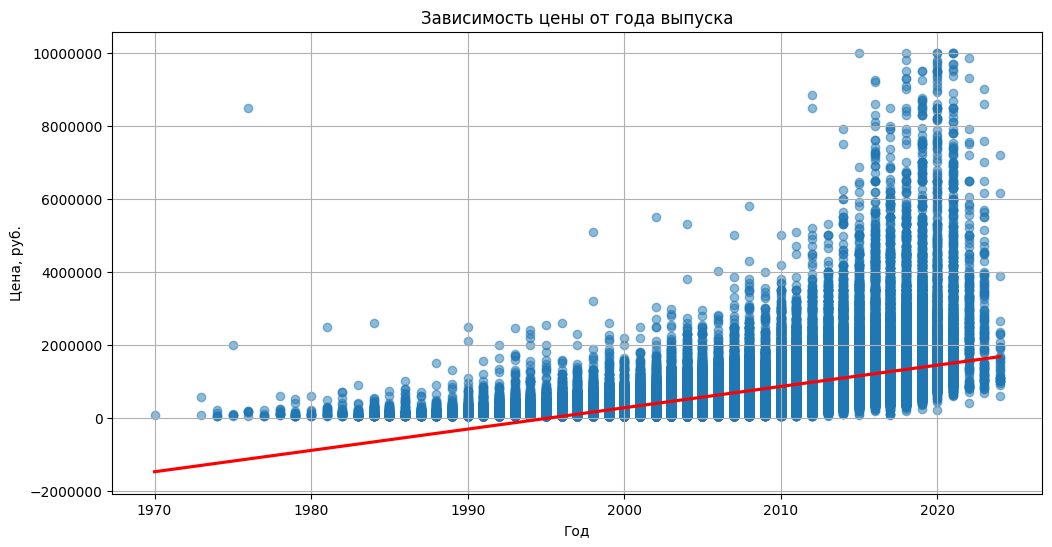

In [12]:
plt.figure(figsize=(12,6))
sns.regplot(x='Год', y='Цена', data=df_eda, scatter_kws={'alpha': 0.5}, line_kws={"color":"red"})
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Зависимость цены от года выпуска')
plt.xlabel("Год")
plt.ylabel("Цена, руб.")
plt.grid(True)

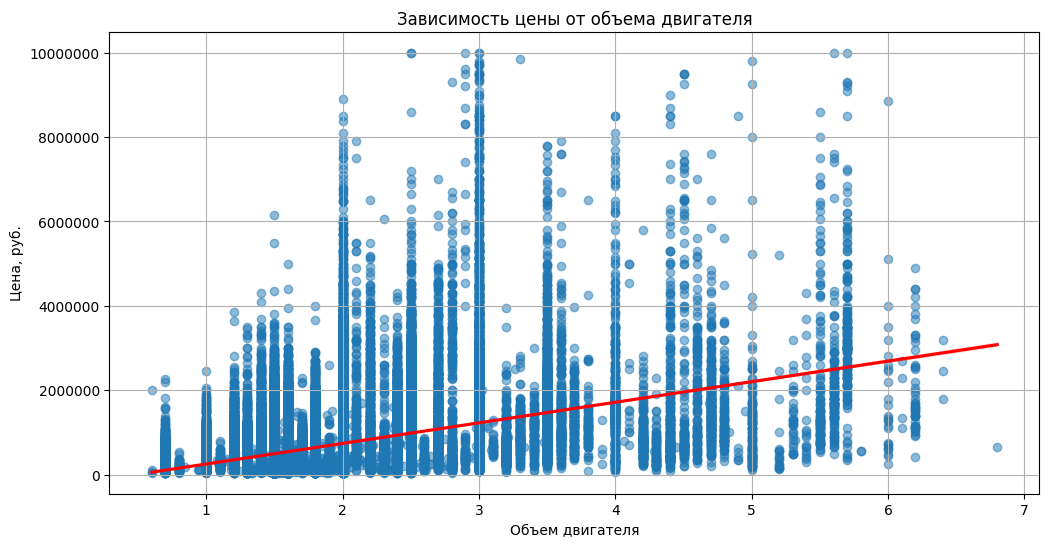

In [13]:
plt.figure(figsize=(12,6))
sns.regplot(x='Объем двигателя', y='Цена', data=df_eda, scatter_kws={'alpha': 0.5}, line_kws={"color":"red"})
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Зависимость цены от объема двигателя')
plt.xlabel("Объем двигателя")
plt.ylabel("Цена, руб.")
plt.grid(True)

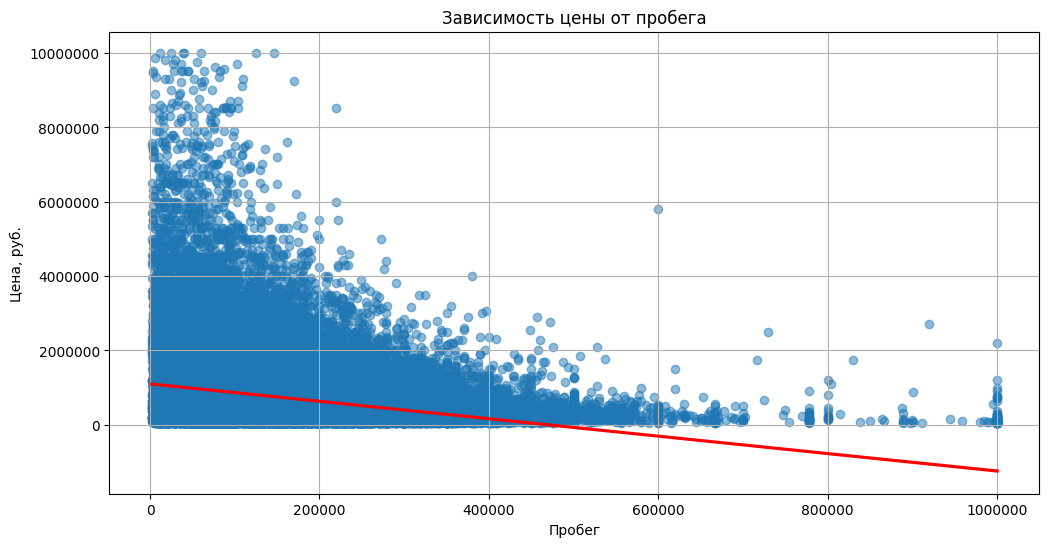

In [14]:
plt.figure(figsize=(12,6))
sns.regplot(x='Пробег', y='Цена', data=df_eda, scatter_kws={'alpha': 0.5}, line_kws={"color":"red"})
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Зависимость цены от пробега')
plt.xlabel("Пробег")
plt.ylabel("Цена, руб.")
plt.grid(True)

Text(0, 0.5, 'Цена, руб.')

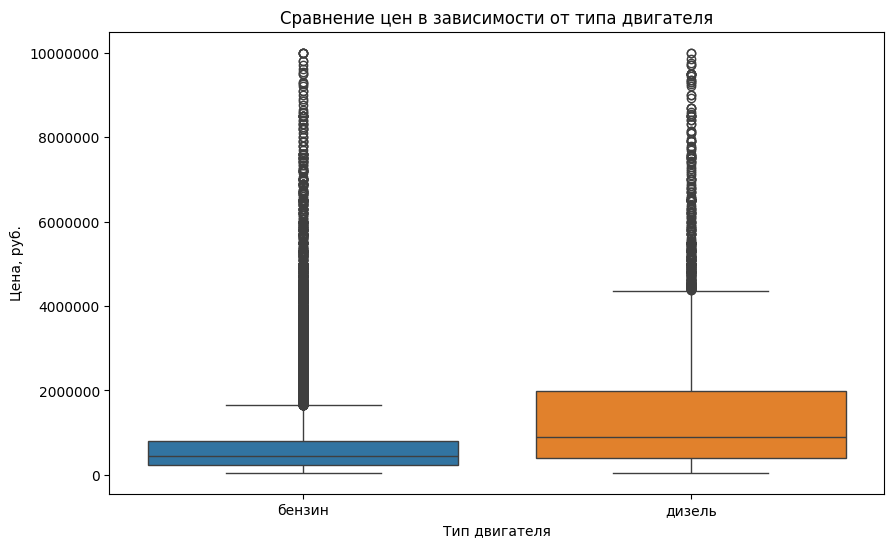

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Тип двигателя', y='Цена', data=df_eda, hue='Тип двигателя')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от типа двигателя')
plt.xlabel("Тип двигателя")
plt.ylabel("Цена, руб.")
# 0 - бензин, 1 - дизель

Text(0, 0.5, 'Цена, руб.')

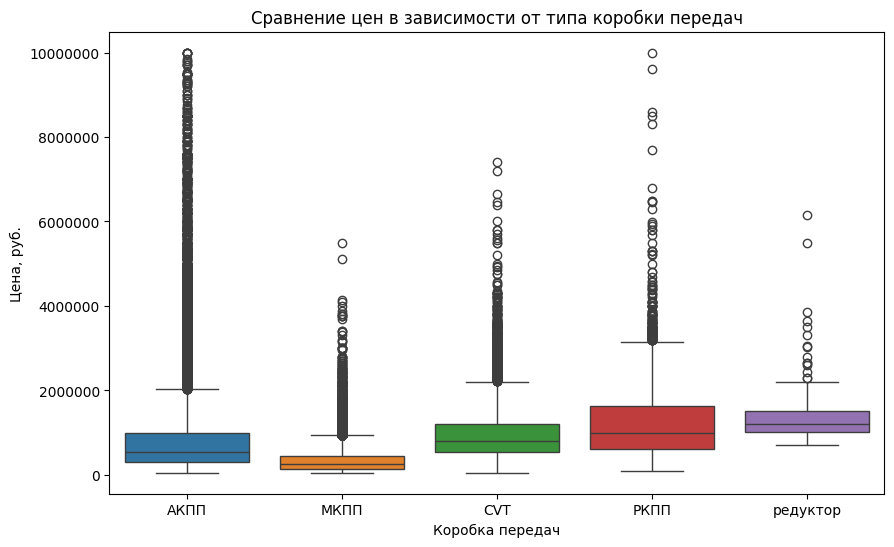

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Коробка передач', y='Цена', data=df_eda, hue='Коробка передач')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от типа коробки передач')
plt.xlabel("Коробка передач")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

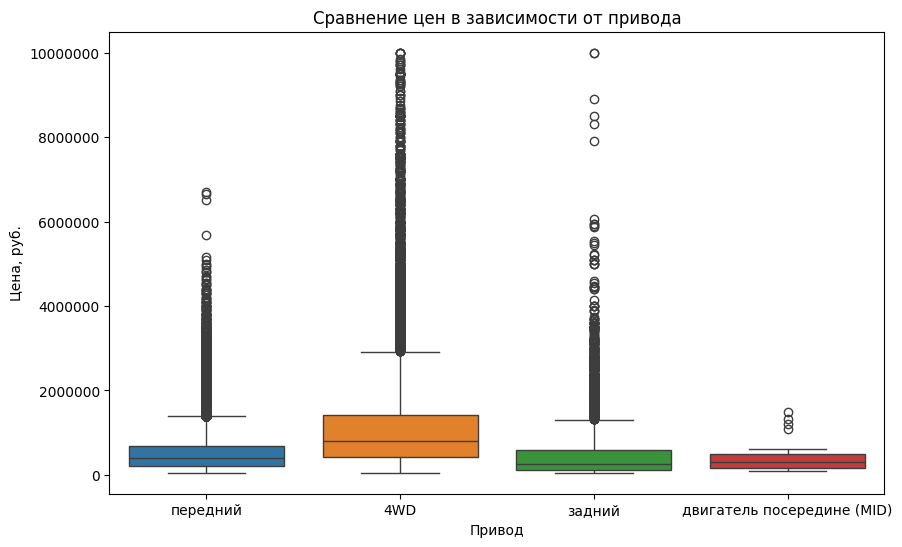

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Привод', y='Цена', data=df_eda, hue='Привод')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от привода')
plt.xlabel("Привод")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

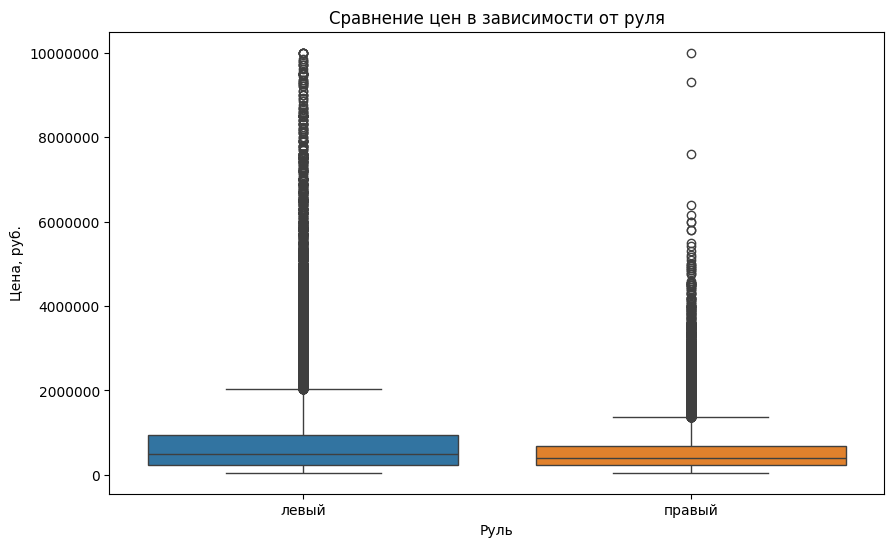

In [37]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Руль', y='Цена', data=df_eda, hue='Руль')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от руля')
plt.xlabel("Руль")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

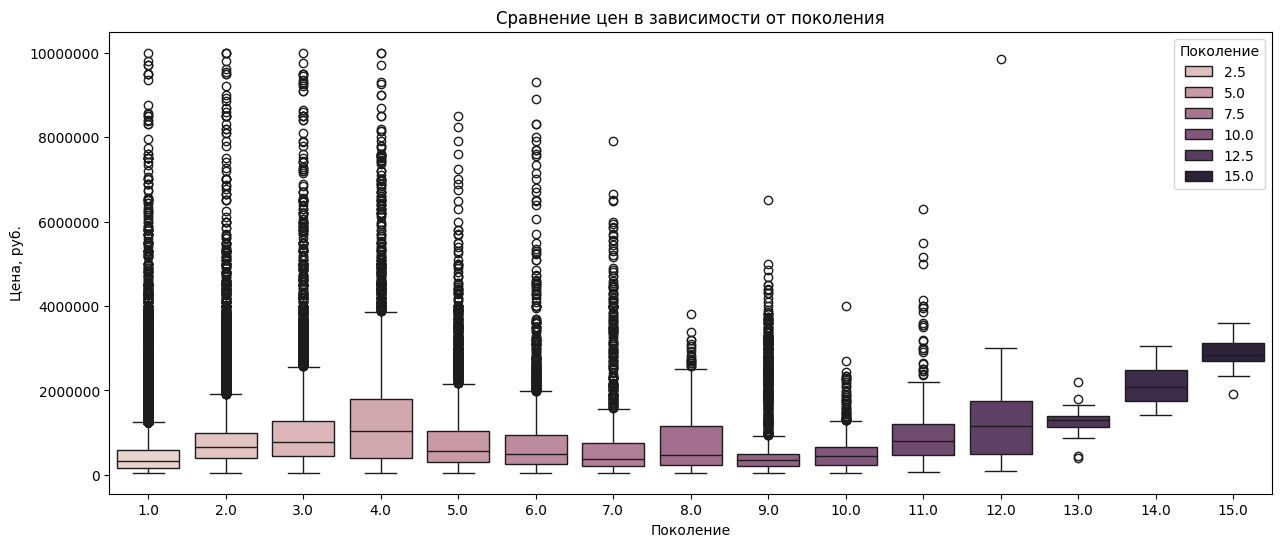

In [43]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Поколение', y='Цена', data=df_eda, hue='Поколение')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от поколения')
plt.xlabel("Поколение")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

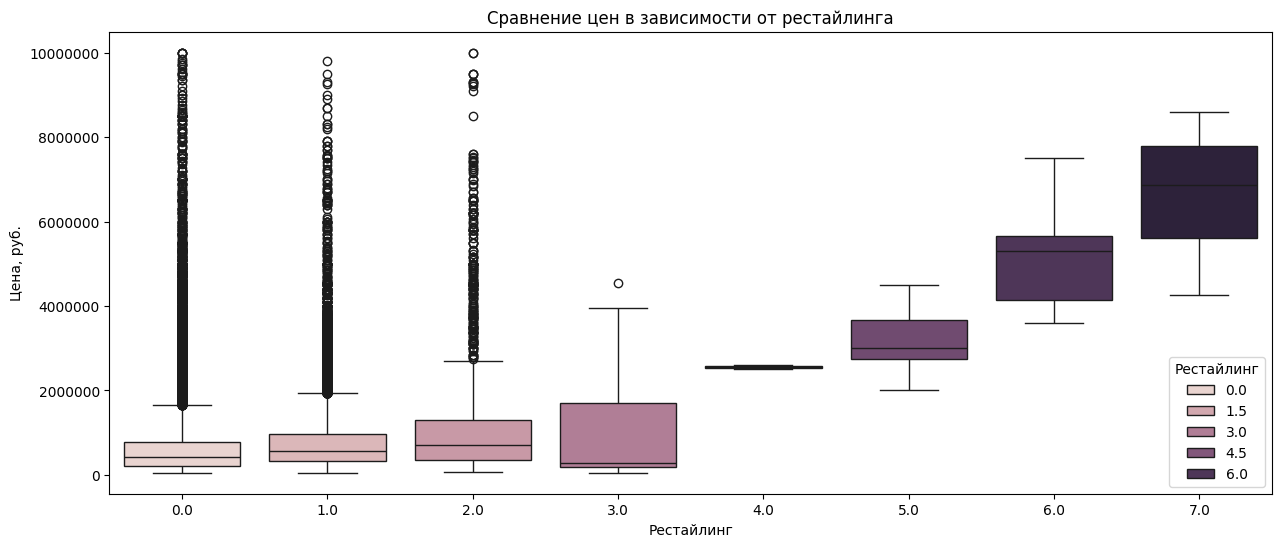

In [46]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Рестайлинг', y='Цена', data=df_eda, hue='Рестайлинг')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от рестайлинга')
plt.xlabel("Рестайлинг")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

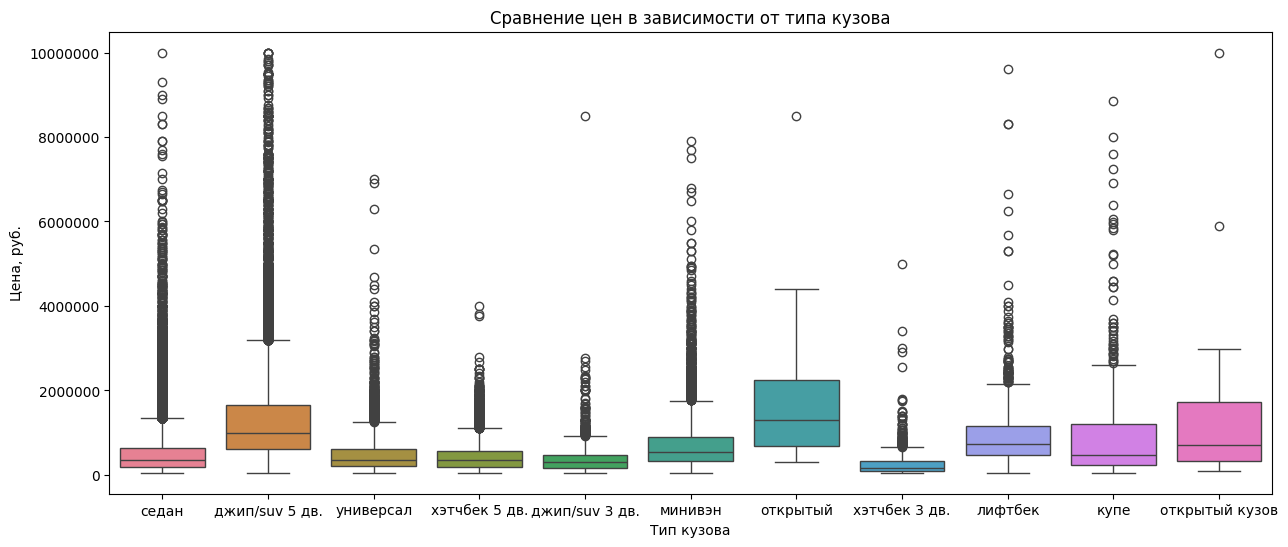

In [47]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Тип кузова', y='Цена', data=df_eda, hue='Тип кузова')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от типа кузова')
plt.xlabel("Тип кузова")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

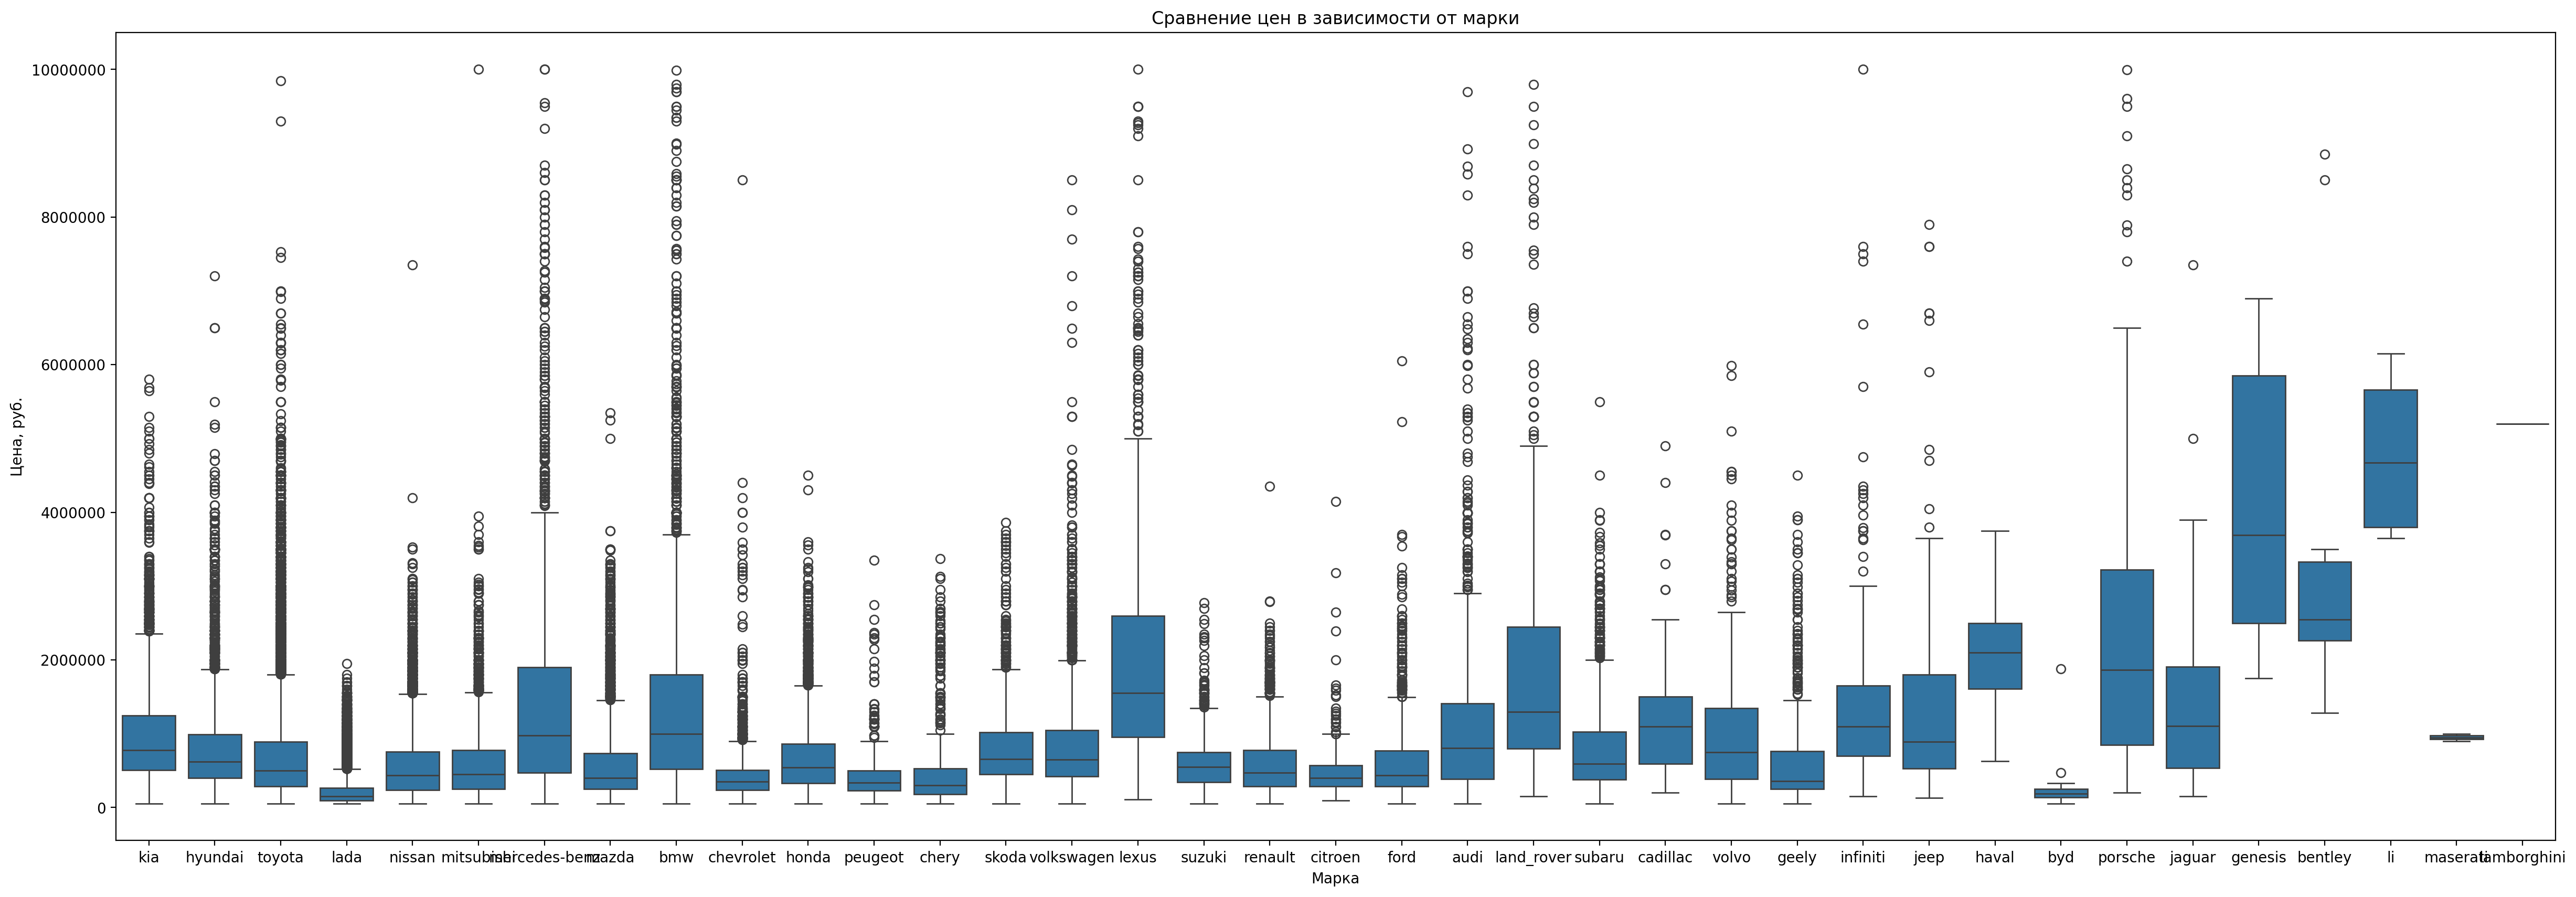

In [48]:
plt.figure(figsize=(30,10), dpi=200)
sns.boxplot(x='Метка', y='Цена', data=df_eda)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от марки')
plt.xlabel("Марка")
plt.ylabel("Цена, руб.")